# MPhil DIS: S1 Coursework 2025/26

*Matt Kenzie*

## The Problem

Your college room mate is a Physics student having some trouble with data analysis. 

They have been asked by their supervisor to determine the performance of a photon detector in their lab. 

Your friend has diligently collected calibration samples in the lab. They have used a laser setup to produce single photons at known fixed Energies (i.e. frequencies) of $E_0$ = [20, 30, 40, 50, 60, 70, 80] GeV and recorded the measured energy, $E$, of the detector (also in GeV, although the units are irrelevant for this problem). They performed $N=1000$ measurements of the energy recorded by the detector, $E$, at each fixed point $E_0$. (Hint: we may assume the supervisor’s lab setup is so sophisticated that the energy uncertainty of the laser itself is negligible - in other words $E_0$ is known exactly with no error). 

Your friend knows, because they asked ChatGPT, that the measured energy (registered by the detection device),
$E$, will be normally distributed, $E\sim \mathcal{N}(\mu_E, \sigma^2_E)$, with mean, 

$$
\mu_E = \lambda E_0 + \Delta,
$$

and a width, $\sigma_E$, given by

$$
\left( \frac{\sigma_E}{E_0} \right)^2 = \left( \frac{a}{\sqrt{E_0}} \right)^2 + \left( \frac{b}{E_0} \right)^2 + c^2.
$$

Your task is to use the input data provided in `sample.csv` (which contains two columns corresponding to the laser energy, $E_0$, and the measured energy, $E$) to provide estimates of the parameters $\{ \lambda, \Delta, a, b, c\}$

# Answers

### Importing Modules


In [1]:
#remove these!!
%load_ext autoreload
%autoreload 2

#importing modules
import matplotlib.pyplot as plt
import os
from s1_sol import main

main.set_mpl_style()
df = main.load_data()


Style applied


## 1) Plotting Sample Estimates
**10 marks**


### 1(i) Plot total sample
- Get hold of your data sample, `sample.csv`, and make a plot of the measured energy, `E`, minus the true energy, `E_0`. This plot should be saved in `figs/Figure1.1.pdf`.

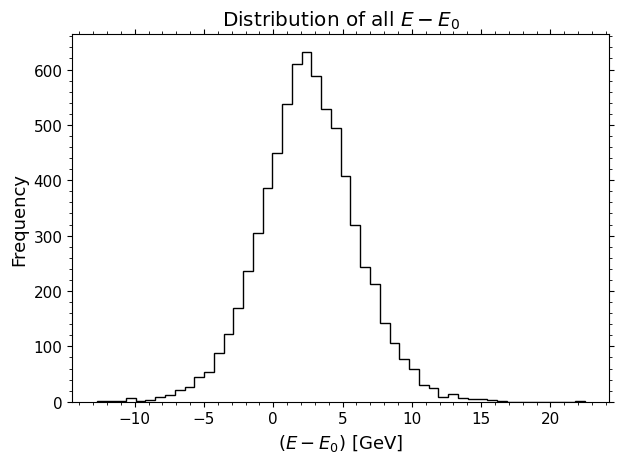

In [30]:
from s1_sol import q1

fig, ax = q1.plot_total_hist(df)

os.system("mkdir -p ../figs")
fig.savefig("../figs/Figure1.1.pdf")

### 1(ii) Overlay samples at each $E_0$
- Make a plot which shows the distribution of `E - E_0`, with the histograms for each different value of `E_0` overlaid. This plot should be saved in `figs/Figure1.2.pdf`

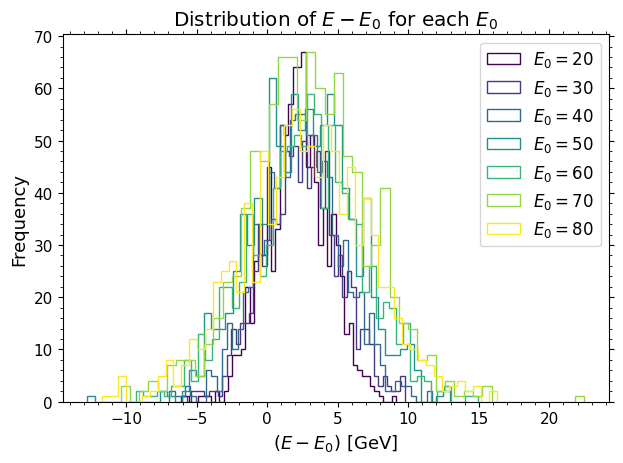

In [17]:
fig, ax = q1.plot_overlapping_hist(df)

fig.savefig("../figs/Figure1.2.pdf")

### 1(iii) Sample estimates
- Produce sample estimates of the mean, $\hat{\mu}_{\rm samp}$, and standard deviation, $\hat{\sigma}_{\rm samp}$, of $E$ at each value of $E_0$. These should be presented along with sample estimates of the error on these estimates (i.e. the standard error on the mean and the standard error on the standard deviation).
- Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$. This figure should be saved to `figs/Figure1.3.pdf`

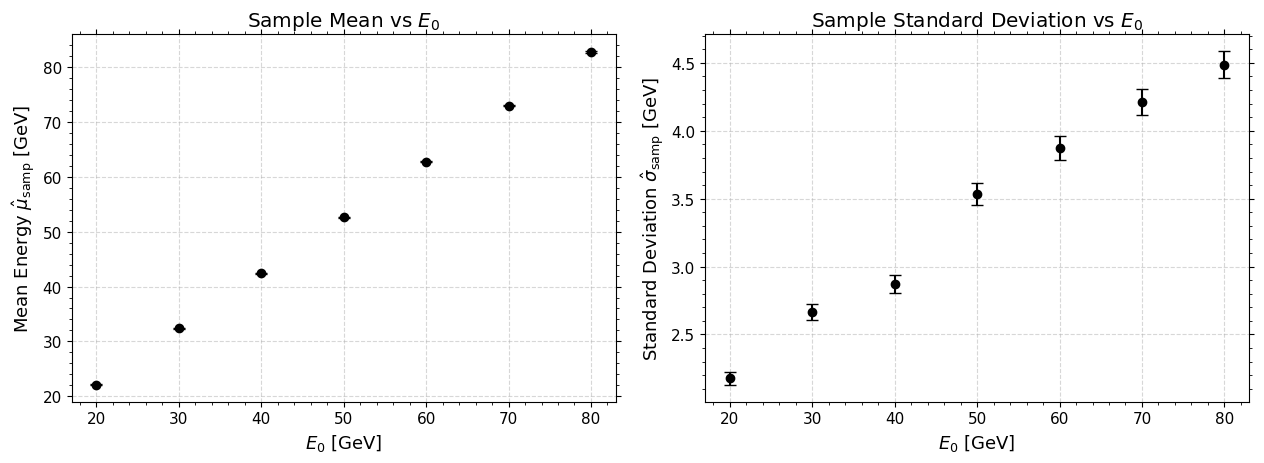

In [32]:
fig, ax, values = q1.plot_sample_estimates(df)

fig.savefig("../figs/Figure1.3.pdf")

### 1(iv) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly into the `results.json` file
- The previously made plots don't have a particular sensible y-scale. Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$ **but this time realign the y-scale** so that you plot $\hat{\mu}_{\rm samp} - E_0$ and $\hat{\sigma}_{\rm samp} / E_0$. You should also **overlay the fitted curves** and add error bands ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure1.4.pdf`

Fitted parameter values:
λ = 1.012 ± 0.002
Δ = 1.964 ± 0.087
a = 0.387 ± 0.060
b = 1.127 ± 0.376
c = 0.034 ± 0.008 



/Users/harvey/Documents/Cambridge/S1/S1 Coursework/hb747/s1_sol/q1.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  return fig, ax


{'sample_ests': {'values': {'lb': 1.0119791031754453, 'dE': 1.9638108269517685, 'a': 0.38742714100624226, 'b': 1.1267206906995624, 'c': 0.034258444999290316}, 'errors': {'lb': 0.0019486017015577187, 'dE': 0.0867810444932158, 'a': 0.059524036904728045, 'b': 0.3760185388384192, 'c': 0.0076918777672117895}}, 'individual_fits': {'values': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}, 'errors': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}}, 'simultaneous_fit': {'values': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}, 'errors': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}}}
{'sample_ests': {'values': {'lb': 1.0119791031754453, 'dE': 1.9638108269517685, 'a': 0.38742714100624226, 'b': 1.1267206906995624, 'c': 0.034258444999290316}, 'errors': {'lb': 0.0019486017015577187, 'dE': 0.0867810444932158, 'a': 0.059524036904728045, 'b': 0.3760185388384192, 'c': 0.0076918777672117895}}, 'individual_fits': {'values': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}, 'er

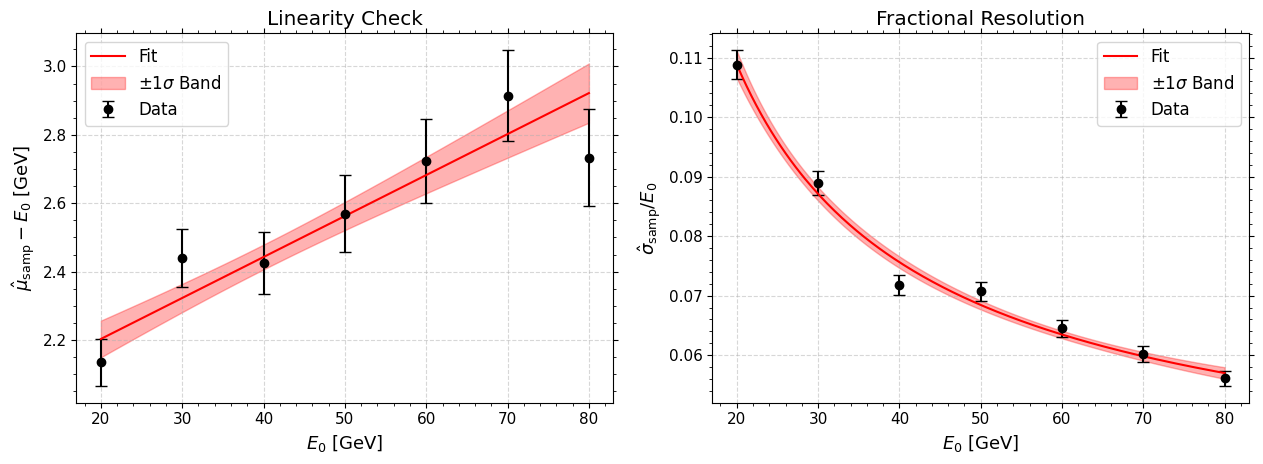

In [34]:
results, fig = q1.plot_fitted_sample_estimates(values)
q1.update_results_json(results,"sample_ests")

fig.savefig("../figs/Figure1.4.pdf")

## 2) Individual Fits
**10 marks**

### 2(i) Normal fits
- Now instead of sample estimates for the mean and width, perform and unbinned maximum likelihood fit of the distribution of $E$ at each value of $E_0$ using a normal distribution to determine the mean, $\hat{\mu}_{\rm indiv}$, and width, $\hat{\sigma}_{\rm indiv}$, (as well as their errors) at each $E_0$
- Make two plots (sub-axes of the same figure). The left should show the distribution of $E-E_0$ (with the distribution at each value of $E_0$ overlaid) also overlaying the result of the normal likelihood fits. The right should show the distribution of $E - E_0$ for all values and then overlay the appropriately normalised sum of sub-distributions. This plot should be saved in `figs/Figure2.1.pdf`

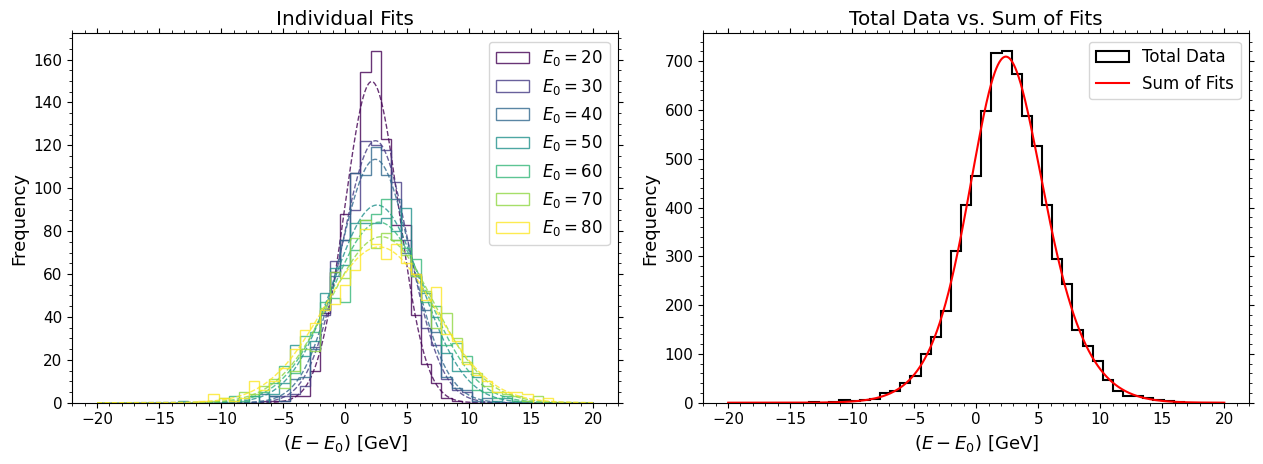

In [51]:
from s1_sol import q2

mle_results, fig = q2.plot_unbinned_mle(df)

fig.savefig('../figs/Figure2.1.pdf')

### 2(ii) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted values $\hat{\mu}_{\rm indiv} - E_0$ and $\hat{\sigma}_{\rm indiv}/E_0$ as a function of $E_0$ **as well as** the fitted curves. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure2.2.pdf`

Fitted parameter values:
λ = 1.012 ± 0.002
Δ = 1.964 ± 0.087
a = 0.387 ± 0.059
b = 1.126 ± 0.376
c = 0.034 ± 0.008 



/Users/harvey/Documents/Cambridge/S1/S1 Coursework/hb747/s1_sol/q1.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  ax.set_title(r'Distribution of all $E - E_0$')


{'sample_ests': {'values': {'lb': 1.0119791031754453, 'dE': 1.9638108269517685, 'a': 0.38742714100624226, 'b': 1.1267206906995624, 'c': 0.034258444999290316}, 'errors': {'lb': 0.0019486017015577187, 'dE': 0.0867810444932158, 'a': 0.059524036904728045, 'b': 0.3760185388384192, 'c': 0.0076918777672117895}}, 'individual_fits': {'values': {'lb': 1.011979103016206, 'dE': 1.9638108428430576, 'a': 0.38723340758233404, 'b': 1.1261570037675752, 'c': 0.034241308182735145}, 'errors': {'lb': 0.0019476277177730046, 'dE': 0.0867376649425682, 'a': 0.059464556067845266, 'b': 0.3756422904695253, 'c': 0.007684183359104301}}, 'simultaneous_fit': {'values': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}, 'errors': {'lb': nan, 'dE': nan, 'a': nan, 'b': nan, 'c': nan}}}
{'sample_ests': {'values': {'lb': 1.0119791031754453, 'dE': 1.9638108269517685, 'a': 0.38742714100624226, 'b': 1.1267206906995624, 'c': 0.034258444999290316}, 'errors': {'lb': 0.0019486017015577187, 'dE': 0.0867810444932158, 'a': 0.059

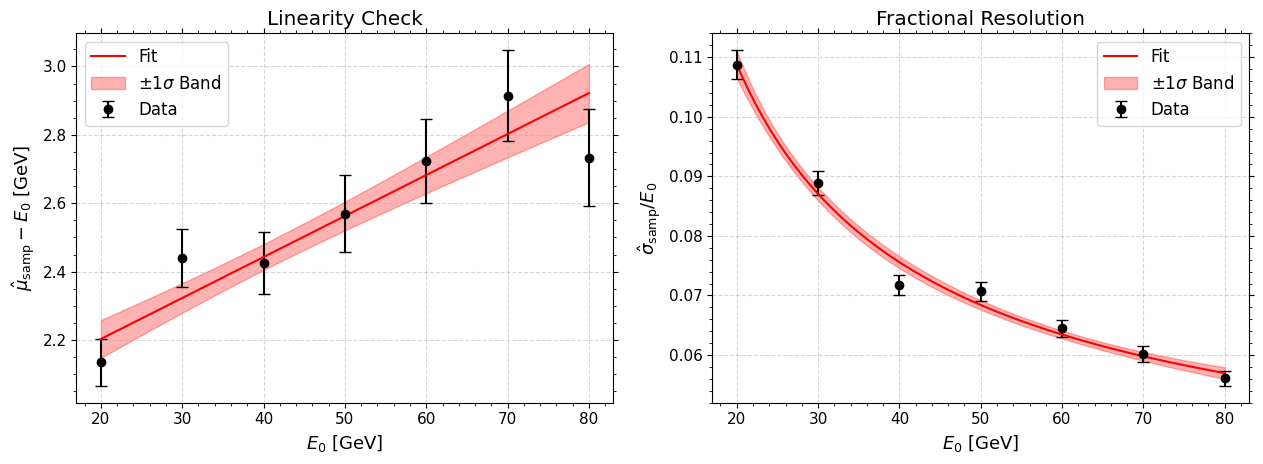

In [53]:
results, fig = q1.plot_fitted_sample_estimates(mle_results)
q1.update_results_json(results,"individual_fits")

fig.savefig("../figs/Figure2.2.pdf")

## 3.) Simultaneous Fit
**10 marks**

### 3(i) the simultaneous likelihood
- Write down an equation for the simultaneous likelihood in which all points are fitted together, i.e. directly fitting the sample for $\lambda$, $\Delta$, $a$, $b$ and $c$
- Appropriately code this and perform an unbinned maximum likelihood fit to all $E_0$ bins simultaneously, to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted curves for $\mu_E$ and $\sigma_E$ as a function of $E_0$. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. You should stick to the convention of plotting $\mu_E - E_0$ and $\sigma_E / E_0$ as a function of $E_0$. This figure should be saved to `figs/Figure3.1.pdf`

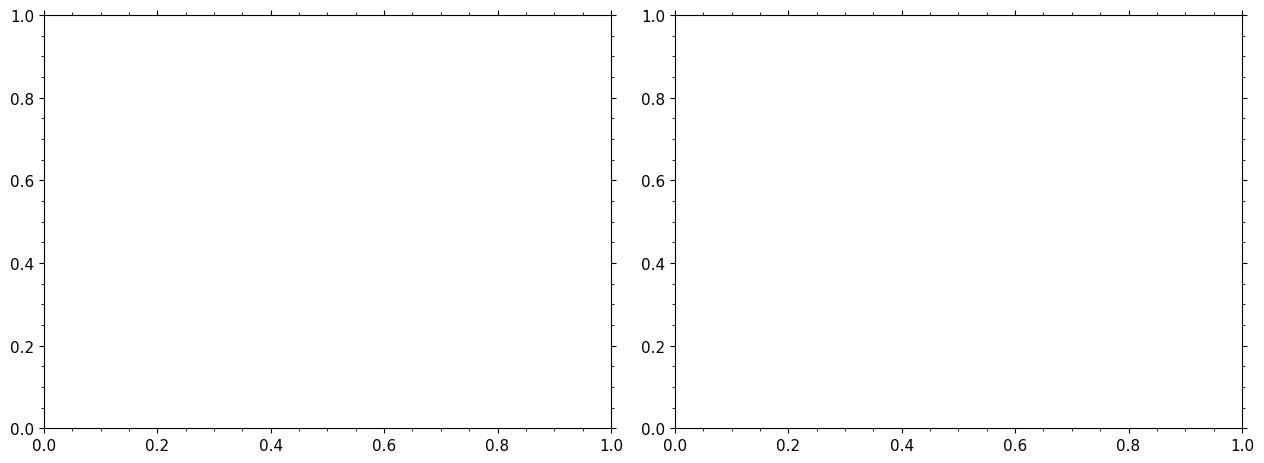

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))

# put your code here

fig.savefig("../figs/Figure3.1.pdf")

### 3(ii) saving the results
- At this point you should have estimates of the five parameters, $\{\lambda, \Delta, a, b, c\}$, (along with their errors), using three different methods: "a sample estimate", "individual fits" and "a simultaneous fit".
- Ensure these are now saved into the `results.json` file in the correct format

In [9]:
from s1_sol import example

ImportError: cannot import name 'example' from 's1_sol' (/Users/harvey/Documents/Cambridge/S1/S1 Coursework/hb747/s1_sol/__init__.py)

### 3(iii) comparing the results
- Make a plot which shows the estimate and error of each parameter, labelling the different estimation types with different colours.
- The parameters may well have rather different values so you will need to think carefully about how you present this information in a sensible way.
- You should save this in a file called `figs/Figure3.2.pdf`

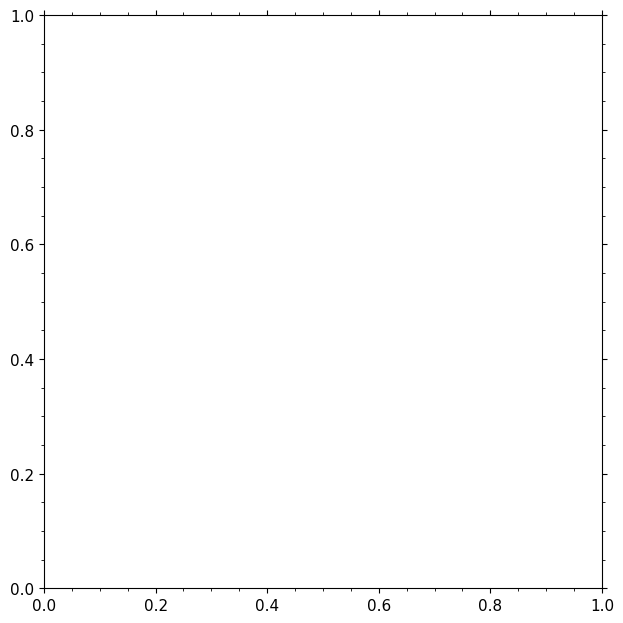

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))

# put your code here

fig.savefig("../figs/Figure3.2.pdf")

## 4.) Bootstrap entire sample
**20 marks**
- Run a non-parameteric bootstrap on the entire analysis using sampling with replacement (and 2500 samples). For reference on my machine this takes ~1 min)
- Produce a figure with 5 subfigures which shows histograms of the bootstrapped values with each method overlaid as a separate colour. You should save this plot in a file called `figs/Figure4.1.pdf`
- Produce a second figure which is the same in style to the plot produced in 3(iii) above this time using the bootstrapped sample to estimate the value and error. You should overlay both sets of points (i.e. the values and errors from parts 1-3 and also the bootstrapped values and errors from part 4). You should save this plot in a file called `figs/Figure4.2.pdf`

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\D'
/var/folders/d_/z7l2kknn76jfzg_bnx_3041h0000gn/T/ipykernel_78865/591338864.py:4: SyntaxWarning: invalid escape sequence '\l'
  ax[0,0].set_xlabel("$\lambda$")
/var/folders/d_/z7l2kknn76jfzg_bnx_3041h0000gn/T/ipykernel_78865/591338864.py:5: SyntaxWarning: invalid escape sequence '\D'
  ax[0,1].set_xlabel("$\Delta$")


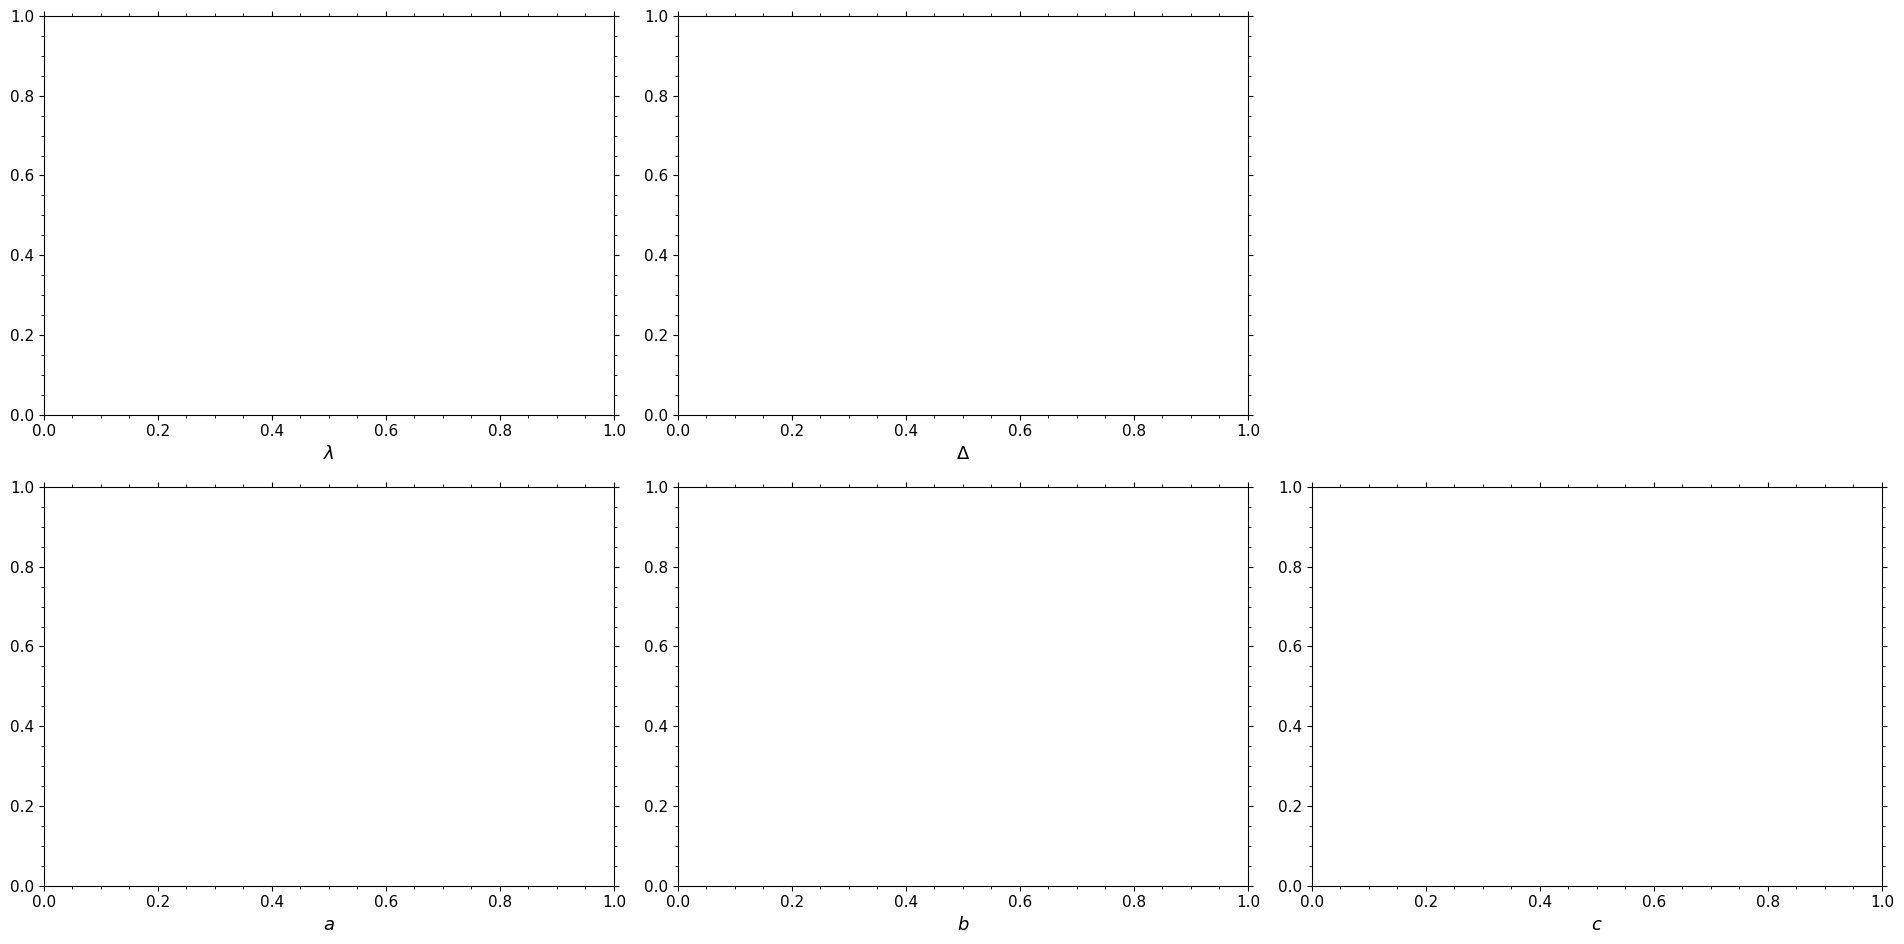

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(19.2, 9.6))

# put your code here
ax[0,0].set_xlabel("$\lambda$")
ax[0,1].set_xlabel("$\Delta$")
ax[0,2].set_visible(False)
ax[1,0].set_xlabel("$a$")
ax[1,1].set_xlabel("$b$")
ax[1,2].set_xlabel("$c$")

fig.savefig("../figs/Figure4.1.pdf")

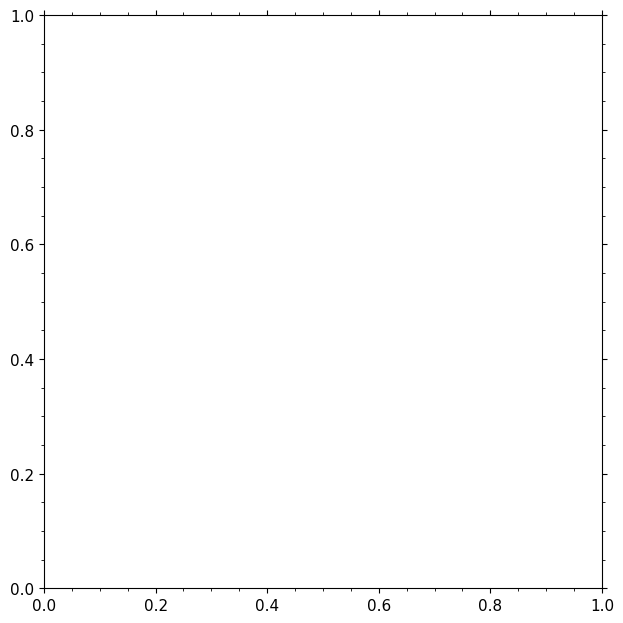

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))

# put your code here

fig.savefig("../figs/Figure4.2.pdf")

## 5.) Discussion of Results
**20 marks**

- Please briefly discuss your findings in no more than 500 words. Do you find what you would naively expect? Can you comment on any discrepancies you see? Would you redesign the analysis in any way?

In [ ]:
# Markdown discussion, code and references to plots here